# Improved Climate Risk Mapping Notebook

This version fixes the broken feature names from the original notebook, adds imputation for lag and rolling features, uses a stronger classification workflow for the small dataset, and replaces the LSTM rainfall forecast with a tabular next-month rainfall model that is usually more stable on about 72 monthly observations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    mean_absolute_error,
)

In [2]:
# Load data
spei = pd.read_csv('SPEI_0.75_35.75.csv')

rain = pd.read_excel(
    'monthly gridded pptn 2019-2024 (1).xlsx',
    sheet_name='monthly gridded pptn 2019-2024'
)
tmax = pd.read_excel(
    'monthly gridded pptn 2019-2024 (1).xlsx',
    sheet_name='monthly gridded tmax 2019-2024'
)
tmin = pd.read_excel(
    'monthly gridded pptn 2019-2024 (1).xlsx',
    sheet_name='monthly gridded tmin 2019-2024'
)

In [3]:
# Parse SPEI dates and keep the matching period
spei['date'] = pd.to_datetime(spei['DATA'], format='%b%Y', errors='coerce')
spei = spei[(spei['date'] >= '2019-01-01') & (spei['date'] <= '2024-12-01')].copy()
spei = spei[['date', 'SPEI_1', 'SPEI_3', 'SPEI_6', 'SPEI_12']]

def clean_gridded(df, value_name):
    df = df.copy()
    df.columns = ['period', value_name]
    df = df.dropna(subset=['period']).copy()

    df['period'] = df['period'].astype(str).str.strip()
    df = df[df['period'].str.fullmatch(r'\d{6}')].copy()

    df['date'] = pd.to_datetime(df['period'], format='%Y%m', errors='coerce')
    df[value_name] = pd.to_numeric(df[value_name], errors='coerce')

    df = df.dropna(subset=['date', value_name]).copy()
    return df[['date', value_name]]

pptn = clean_gridded(rain, 'rainfall')
tmax = clean_gridded(tmax, 'tmax')
tmin = clean_gridded(tmin, 'tmin')

df = (
    pptn
    .merge(tmax, on='date', how='inner')
    .merge(tmin, on='date', how='inner')
    .merge(spei, on='date', how='inner')
    .sort_values('date')
    .reset_index(drop=True)
)

print(df.head())
print(df.shape)

        date  rainfall      tmax      tmin   SPEI_1   SPEI_3   SPEI_6  SPEI_12
0 2019-01-01    23.309  27.02848  12.31526  0.03930  0.24262 -0.23133  1.53012
1 2019-02-01    28.977  27.70414  13.95043 -0.53185  0.22618 -0.09578  1.36099
2 2019-03-01    63.319  29.06606  13.70274 -0.94066 -0.93436 -0.07414  0.90310
3 2019-04-01   133.315  29.01347  14.85820 -1.03191 -1.42567 -0.87047 -0.05929
4 2019-05-01    92.008  27.86090  15.09035 -0.81321 -1.48783 -1.12400 -0.84499
(72, 8)


In [4]:
# Feature engineering
data = df.copy()

data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year
data['quarter'] = data['date'].dt.quarter

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

data['temp_mean'] = (data['tmax'] + data['tmin']) / 2
data['temp_range'] = data['tmax'] - data['tmin']

data['rain_3m_mean'] = data['rainfall'].rolling(window=3).mean()
data['rain_6m_mean'] = data['rainfall'].rolling(window=6).mean()

data['tmax_3m_mean'] = data['tmax'].rolling(window=3).mean()
data['tmin_3m_mean'] = data['tmin'].rolling(window=3).mean()
data['temp_mean_3m'] = data['temp_mean'].rolling(window=3).mean()

data['rain_3m_std'] = data['rainfall'].rolling(window=3).std()
data['temp_mean_3m_std'] = data['temp_mean'].rolling(window=3).std()

for lag in [1, 2, 3]:
    data[f'rainfall_lag_{lag}'] = data['rainfall'].shift(lag)
    data[f'tmax_lag_{lag}'] = data['tmax'].shift(lag)
    data[f'tmin_lag_{lag}'] = data['tmin'].shift(lag)
    data[f'SPEI_3_lag_{lag}'] = data['SPEI_3'].shift(lag)
    data[f'SPEI_6_lag_{lag}'] = data['SPEI_6'].shift(lag)

data['rain_anomaly_3m'] = data['rainfall'] - data['rain_3m_mean']
data['temp_anomaly_3m'] = data['temp_mean'] - data['temp_mean_3m']

print(data.head())

        date  rainfall      tmax      tmin   SPEI_1   SPEI_3   SPEI_6  \
0 2019-01-01    23.309  27.02848  12.31526  0.03930  0.24262 -0.23133   
1 2019-02-01    28.977  27.70414  13.95043 -0.53185  0.22618 -0.09578   
2 2019-03-01    63.319  29.06606  13.70274 -0.94066 -0.93436 -0.07414   
3 2019-04-01   133.315  29.01347  14.85820 -1.03191 -1.42567 -0.87047   
4 2019-05-01    92.008  27.86090  15.09035 -0.81321 -1.48783 -1.12400   

   SPEI_12  month  year  ...  tmin_lag_2  SPEI_3_lag_2  SPEI_6_lag_2  \
0  1.53012      1  2019  ...         NaN           NaN           NaN   
1  1.36099      2  2019  ...         NaN           NaN           NaN   
2  0.90310      3  2019  ...    12.31526       0.24262      -0.23133   
3 -0.05929      4  2019  ...    13.95043       0.22618      -0.09578   
4 -0.84499      5  2019  ...    13.70274      -0.93436      -0.07414   

   rainfall_lag_3  tmax_lag_3  tmin_lag_3  SPEI_3_lag_3  SPEI_6_lag_3  \
0             NaN         NaN         NaN           NaN

In [5]:
# Risk labels
def classify_risk(row, rain_high_threshold):
    if row['SPEI_3'] <= -0.01 or row['SPEI_6'] <= -0.1:
        return 'drought'
    elif row['rainfall'] >= rain_high_threshold:
        return 'flood'
    else:
        return 'normal'

rain_high_threshold = data['rainfall'].quantile(0.60)
data['risk_level'] = data.apply(
    lambda row: classify_risk(row, rain_high_threshold),
    axis=1
)

print(data['risk_level'].value_counts())

risk_level
drought    25
normal     24
flood      23
Name: count, dtype: int64


In [6]:
# Classification features
feature_cols = [
    'rainfall',
    'tmax',
    'tmin',
    'temp_mean',
    'temp_range',
    'SPEI_1',
    'SPEI_3',
    'SPEI_6',
    'SPEI_12',
    'rain_3m_mean',
    'rain_6m_mean',
    'tmax_3m_mean',
    'tmin_3m_mean',
    'temp_mean_3m',
    'rain_3m_std',
    'temp_mean_3m_std',
    'rainfall_lag_1',
    'rainfall_lag_2',
    'rainfall_lag_3',
    'tmax_lag_1',
    'tmax_lag_2',
    'tmax_lag_3',
    'tmin_lag_1',
    'tmin_lag_2',
    'tmin_lag_3',
    'SPEI_3_lag_1',
    'SPEI_3_lag_2',
    'SPEI_3_lag_3',
    'SPEI_6_lag_1',
    'SPEI_6_lag_2',
    'SPEI_6_lag_3',
    'rain_anomaly_3m',
    'temp_anomaly_3m',
    'month_sin',
    'month_cos',
]

X = data[feature_cols]
y = data['risk_level']

split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (57, 35)
Test size: (15, 35)


In [7]:
# Time-aware model tuning
tscv = TimeSeriesSplit(n_splits=4)

clf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
])

param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 4, 5, 6, None],
    'model__min_samples_split': [2, 4, 6, 8],
    'model__min_samples_leaf': [1, 2, 3, 4],
}

grid_search = GridSearchCV(
    estimator=clf_pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

print('Best Params:', grid_search.best_params_)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Weighted F1:', f1_score(y_test, y_pred, average='weighted'))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Fitting 4 folds for each of 160 candidates, totalling 640 fits
Best Params: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Accuracy: 0.9333333333333333
Weighted F1: 0.9322638146167558

              precision    recall  f1-score   support

     drought       1.00      1.00      1.00         1
       flood       1.00      0.83      0.91         6
      normal       0.89      1.00      0.94         8

    accuracy                           0.93        15
   macro avg       0.96      0.94      0.95        15
weighted avg       0.94      0.93      0.93        15



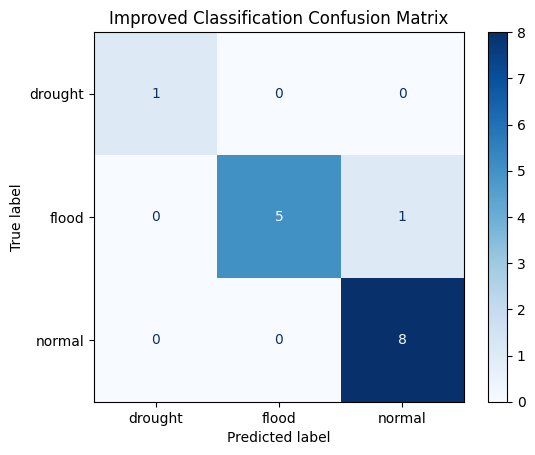

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_clf.named_steps['model'].classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_clf.named_steps['model'].classes_
)
disp.plot(cmap='Blues')
plt.title('Improved Classification Confusion Matrix')
plt.show()

         feature  importance
0       rainfall    0.471560
6         SPEI_3    0.383266
7         SPEI_6    0.145174
2           tmin    0.000000
1           tmax    0.000000
4     temp_range    0.000000
3      temp_mean    0.000000
5         SPEI_1    0.000000
8        SPEI_12    0.000000
9   rain_3m_mean    0.000000
10  rain_6m_mean    0.000000
11  tmax_3m_mean    0.000000
12  tmin_3m_mean    0.000000
13  temp_mean_3m    0.000000
14   rain_3m_std    0.000000


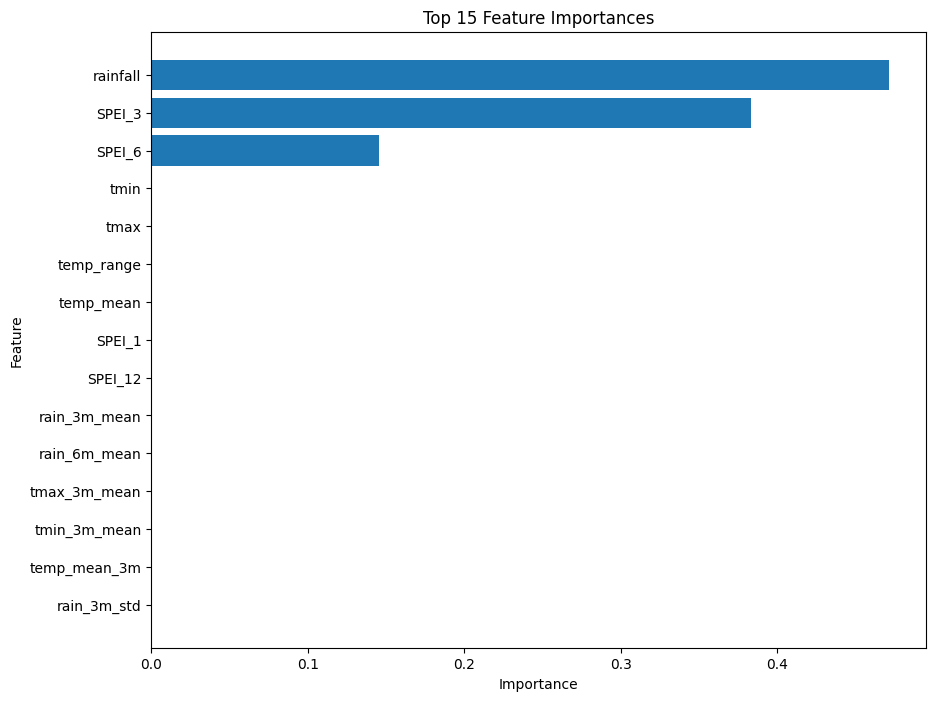

In [9]:
# Decision tree feature importance sensitivity analysis
model = best_clf.named_steps['model']

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['feature'].head(15)[::-1],
    importance_df['importance'].head(15)[::-1]
)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [10]:
# Rainfall forecasting target: next month's rainfall
forecast_data = data.copy()

for lag in [1, 2, 3, 6]:
    forecast_data[f'target_rain_lag_{lag}'] = forecast_data['rainfall'].shift(lag)

forecast_data['target_rain_3m_mean'] = forecast_data['rainfall'].rolling(3).mean()
forecast_data['target_rain_6m_mean'] = forecast_data['rainfall'].rolling(6).mean()

forecast_data['rainfall_next_month'] = forecast_data['rainfall'].shift(-1)
forecast_data = forecast_data.iloc[:-1].copy()

reg_features = [
    'rainfall',
    'tmax',
    'tmin',
    'temp_mean',
    'temp_range',
    'SPEI_1',
    'SPEI_3',
    'SPEI_6',
    'SPEI_12',
    'rainfall_lag_1',
    'rainfall_lag_2',
    'rainfall_lag_3',
    'month_sin',
    'month_cos',
    'rain_3m_mean',
    'rain_6m_mean',
    'rain_3m_std',
    'rain_anomaly_3m',
    'target_rain_lag_6',
    'target_rain_3m_mean',
    'target_rain_6m_mean',
]

X_reg = forecast_data[reg_features]
y_reg = forecast_data['rainfall_next_month']

split_reg = int(len(forecast_data) * 0.8)

X_reg_train = X_reg.iloc[:split_reg].copy()
X_reg_test = X_reg.iloc[split_reg:].copy()
y_reg_train = y_reg.iloc[:split_reg].copy()
y_reg_test = y_reg.iloc[split_reg:].copy()

print(X_reg_train.shape, X_reg_test.shape)

(56, 21) (15, 21)


In [11]:
# Tabular rainfall forecasting model
reg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=3,
        max_iter=200
    )),
])

reg_pipe.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_pipe.predict(X_reg_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)

# naive baseline: next month ~= previous observed month
naive_pred = forecast_data['rainfall'].shift(1).iloc[split_reg:]
baseline_rmse = np.sqrt(mean_squared_error(y_reg_test, naive_pred))
baseline_mae = mean_absolute_error(y_reg_test, naive_pred)

print('Improved RMSE:', rmse)
print('Improved MAE:', mae)
print('Naive baseline RMSE:', baseline_rmse)
print('Naive baseline MAE:', baseline_mae)

Improved RMSE: 105.68530102222024
Improved MAE: 85.58066933176784
Naive baseline RMSE: 169.92361813140238
Naive baseline MAE: 149.00860000000003


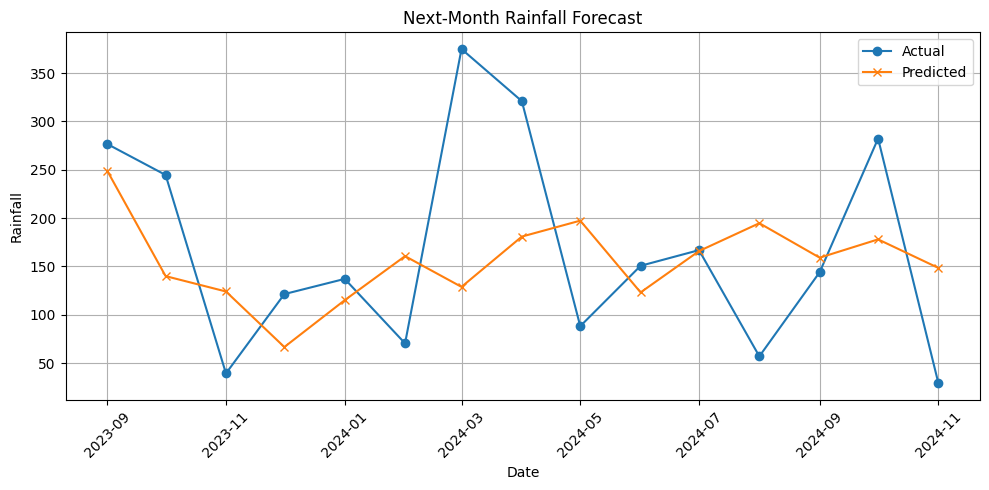

,date,actual_rainfall_next_month,predicted_rainfall_next_month
0,2023-09-01,276.642,248.999291
1,2023-10-01,244.609,140.018485
2,2023-11-01,39.407,124.117992
3,2023-12-01,121.434,66.693348
4,2024-01-01,137.153,115.134156


In [12]:
# Plot rainfall forecast
results = pd.DataFrame({
    'date': forecast_data['date'].iloc[split_reg:].values,
    'actual_rainfall_next_month': y_reg_test.values,
    'predicted_rainfall_next_month': y_reg_pred
})

plt.figure(figsize=(10, 5))
plt.plot(results['date'], results['actual_rainfall_next_month'], marker='o', label='Actual')
plt.plot(results['date'], results['predicted_rainfall_next_month'], marker='x', label='Predicted')
plt.title('Next-Month Rainfall Forecast')
plt.xlabel('Date')
plt.ylabel('Rainfall')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

results.head()

In [13]:
# Early warning flag from predicted rainfall
warning_threshold = data['rainfall'].quantile(0.80)

warnings = results.copy()
warnings['early_warning'] = np.where(
    warnings['predicted_rainfall_next_month'] >= warning_threshold,
    'high_rain_alert',
    'normal'
)

warnings.head(10)

,date,actual_rainfall_next_month,predicted_rainfall_next_month,early_warning
0,2023-09-01,276.642,248.999291,high_rain_alert
1,2023-10-01,244.609,140.018485,normal
2,2023-11-01,39.407,124.117992,normal
3,2023-12-01,121.434,66.693348,normal
4,2024-01-01,137.153,115.134156,normal
5,2024-02-01,70.468,160.681933,normal
6,2024-03-01,374.824,128.893851,normal
7,2024-04-01,320.941,180.914844,normal
8,2024-05-01,88.258,197.381845,normal
9,2024-06-01,150.692,123.185287,normal
